# The SIDFEx user guide 

## Background 

SIDFEx (Sea Ice Drift Forecast Experiment) is a community-effort database which currently (October 2021) comprises more than 168k ice drift forecasts for single buoys, issued by 14 research groups and continuously growing since 2017. The idea originated in 2017 in the framework of the Year of Polar Prediction (YOPP). Since then, the groups regularly submit forecasts which are processed and standardised operationally by a processing chain hosted at DKRZ (German Climate Computation Center/Deutsches Klimarechenzentrum). The data can be downloaded and explored by a software package written in R, called SIDFEx. This user guide allows you to interactively get used to the package and do first analyses with the dataset. It makes no claim to completeness, it is rather meant to give you a first flavour of the software and the dataset. Additionally, there is a PDF version of the user guide which provides more background information and interpretation (user_guide_extensive.pdf).

- Author (software packages): Helge Goessling
- Author (this notebook): Valentin Ludwig
- Author (PDF user guide): Helge Goessling
- Contacts: helge.goessling@awi.de; valentin.ludwig@awi.de
- Creation date: 20211027
- Last used on: 20211027
- Purpose: Try SIDFEx user guide
- Extensive version: user_guide_sidfex_extensive.pdf


## Getting started

**Important note:** This section is only needed for the setup of the package. Once this runs, this section can be skipped.

### Requirements and setting up the SIDFEx package

#### Set paths

Prior to starting: Set paths. To this end, do (according to user guide):
- create a file ~/.SIDFEx in your home dir
- add the line data.path.fcst = "~/SIDFEx/fcst"
- add the line data.path.obs = "~/SIDFEx/obs"
- add the lines indexTable.path.in = "~/SIDFEx/index"

This can be done by executing the shell script "setup_sidfex.bash" which is also provided in this repository. It can be executed by typing 
```/bin/bash setup_sidfex.bash```
in the command line.


*Remark*: In principle, you can also use different filepaths. This is, however, highly *not* recommended because many functions rely on the filepaths being set as above. If the filepaths differ, the functions need to be adapted manually, which is both cumbersome and error-prone.

#### Installing libraries

Two libraries are required in order to use the SIDFEx database. Their names are spheRlab and SIDFEx. Both were developed and are maintained by AWI. They are publicly available on Gitlab and can therefore be installed using the R package "devtools", which is part of the conda environment which comes with this repository.

In [2]:
install.packages("devtools")

also installing the dependencies ‘fastmap’, ‘gert’, ‘gh’, ‘cachem’, ‘ps’, ‘waldo’, ‘usethis’, ‘callr’, ‘desc’, ‘ellipsis’, ‘fs’, ‘httr’, ‘lifecycle’, ‘memoise’, ‘pkgbuild’, ‘pkgload’, ‘rcmdcheck’, ‘rlang’, ‘roxygen2’, ‘testthat’

Warning message in install.packages("devtools"):
“installation of package ‘fastmap’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘rlang’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘cachem’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘waldo’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘lifecycle’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘usethis’ had non-zero exit status”Warning message in install.packages("devtools"):
“installation of package ‘memoise’ had non-zero exit status”Warning me

In [1]:
## Load devtools library (needed to install spheRlab and SIDFEx libraries)
require(devtools)

Loading required package: devtools
Error: package or namespace load failed for ‘devtools’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called ‘rlang’


In [2]:
## Install spheRlab and SIDFEx
#devtools::install_github("FESOM/spheRlab") # install spheRlab
devtools::install_github("helgegoessling/SIDFEx") # install SIDFEx

✔  checking for file ‘/private/var/folders/d6/cf68qnyn42708tqdllr3pbmjmsjrs2/T/RtmpIPkDn9/remotes17d6d520c51e0/helgegoessling-SIDFEx-c50a2a8/DESCRIPTION’ (431ms)
─  preparing ‘SIDFEx’:
✔  checking DESCRIPTION meta-information ...
─  checking for LF line-endings in source and make files and shell scripts
─  checking for empty or unneeded directories
─  building ‘SIDFEx_0.3.1.tar.gz’
   


## Obtaining and handling the data

This section describes how to obtain a local copy of the database. Also, it gives pathways for exploring the dataset. First, we need to load the libraries whose installation is described in Section 1.

In [1]:
## Load libraries
require(spheRlab)
require(SIDFEx)
## Turn off warnings
defaultW = getOption("warn") # save default setting for warnings
options(warn = -1)  # use this line to turn warnings off for now
# options(warn = defaultW) # use this line to turn warnings on with the default settings

Loading required package: spheRlab
Loading required package: SIDFEx


Now, we can download the forecast and observational data. Note that it is important that the filepaths to the ~/SIDFEx/ directory are set as described in Section 1. If you chose a different filepath, you would need to adapt the functions accordingly.

The next cell *downloads* the data, or updates them if new forecasts have been submitted.. If you have already downloaded them previously, there is no need to execute the following cell.

### Downloading forecast and observational data

Each SIDFEx forecast, once submitted by one of the contributing forecast centres, is automatically processed and made publicly available in real-time (<1h delay) at the Cloud Service of the German Climate Computing Centre (DKRZ). Individual forecast files in plain-text format, ordered by contributor GroupIDs, can be accessed individually at <https://swiftbrowser.dkrz.de/public/dkrz_0262ea1f00e34439850f3f1d71817205/SIDFEx_processed/>. However, if more than a few forecasts are of interest, it is much more convenient and faster to download a corresponding `.tar.gz` file that holds all the forecast data. To retrieve it through this package, run

#### Downloading data for the first time

This subsection gives you detailed instructions how to download the data when working for the first time with the dataset. It may be skipped once you have downloaded them and only need to load them from your local machine.

In [2]:
res = sidfex.download.fcst() # If you want to download all data, regardless of whether they have been downloaded already, call the function without arguments (i.e., use this line)


[1] "Creating directory ~/SIDFEx/fcst"
[1] "Index download ..."
[1] "Index download done."
[1] "Data download ..."
[1] "Data download done."
[1] "Returning index of files that have been downloaded, and (if not from.scratch) the more detailed result of sidfex.fcst.search.compareIndexTables"


After successful retrieval, you will find the plain-text forecast files in the specified data directory (see above) in subdirectories named by the `GroupID`s of the forecast centres.

In fact, this function retrieves not only the forecast data, but also an index of the data (which you will now also find in the corresponding directory). The index is basically a table stored in a native R file format (`data.frame`), each row representing a single forecast file with specific information about this forecast. Therefore this table can easily be used to find certain forecasts based on criteria on the columns, comparable to tables in a database management system. The index thus facilitates exploring and working with the data considerably. Once a local copy of the data and a corresponding index exist, the index also allows one to compare the local data with the remote data to see what new data is available. To compare, run

In [4]:
res = sidfex.download.fcst(comparison.mode = TRUE, from.scratch = FALSE) # downloads forecast data which have not been downloaded previously

[1] "Index download ..."
[1] "Index download done."
[1] "Entries only in local index = obsolete files to be deleted: 0"
[1] "Entries only in remote index = new files to be downloaded: 94"
[1] "Identical entries = local files already up-to-date: 198846"
[1] "Entries for same files with differences = files to be downloaded and to replace local ones: 0"
[1] "To execute these downloads and other changes (if present as indicated above), resubmit command with comparison.mode=FALSE ."
[1] "Returning index of files that would be downloaded with comparison.mode=FALSE, and (if not from.scratch) the more detailed result of sidfex.fcst.search.compareIndexTables"


If not too many new forecasts are available and if you want to save download volume, you can rerun the function with `comparison.mode = FALSE` and `from.scratch = FALSE` to retrieve only individual new files. However, `from.scratch = TRUE` will be faster most of the time.

It can be convenient to have the index of the (local) forecast data available in a local variable. To dump the index into a data frame (a type of table common in R) named `index` and to get an overview of its content, run

In [2]:
index = sidfex.load.index()

In [3]:
length(index$File)

[1] 202832

In [ ]:
index = sidfex.load.index() # index is a data frame which describes the data. Note that it does not contain the data themselves. 
obs = sidfex.download.obs(index = index) # Download observation data described by index

The first line of the output tells us how many forecast trajectories ("`obs.`" = number of rows, counting all members of ensemble forecasts individually; note that this has nothing to do with actual *observed* buoy positions, but is R-internal terminology for `data.frame` objects) are available, and how many columns ("`variables`") the index provides, which are listed underneath. For example, the `$TargetID` column provides the target each forecast corresponds to. We can list all targets by selecting the corresponding column of the index table as follows:

In [ ]:
unique(index$TargetID) # get IDs of all targets

To download observational data for all SIDFEx targets, you can use the function `sidfex.download.obs()`. The argument `TargetID` can be used to specify which observations shall be retrieved. However, often the easiest way is to provide the argument `index`, that is, the index of the forecast data for which observations shall be retrieved, directly:

The above download functions rely on the availability of the respective servers and on finding the data in the expected locations and format. If the download fails, please let us know so we can investigate the cause.

Now that we have all data locally, let's start by exploring and subselecting the index, then read some data, then inspect some raw data, and finally look at some more sophisticated examples.

#### Working with already downloaded data

From time to time, it may be necessary to update your local version of the dataset if new forecasts have been submitted online. In this case, use the

```res = sidfex.download.fcst...``` 

lines of the following cell. If you do not want to update your local version, you can comment them out.

In [3]:
require(SIDFEx)

In [4]:
## Downloading forecast and observational data ###
#res = sidfex.download.fcst() # If you want to download all data, regardless of whether they have been downloaded already, call the function without arguments (i.e., use this line)
#res = sidfex.download.fcst(comparison.mode = TRUE, from.scratch = FALSE) # downloads forecast data which have not been downloaded previously (i.e., use this line). 
index = sidfex.load.index() # index is a data frame (smth like a table) which describes the data. Note that it does not contain the data themselves. 
#obs = sidfex.download.obs(index = index) # Download observation data described by index

Having downloaded the data and having loaded the index which describes them, we now can dive into exploring the dataset using this index. First, we get an overview over the available systems. "System" is the combination of forecast center and method.

In [5]:
## Get list of systems (GroupID and MethodID)
systms = paste(index$GroupID, index$MethodID, sep = "_") # Get system list as GroupID_MethodID
systms_unique = unique(systms) # Retrieve unique names
#systms_unique = systms_unique[systms_unique != "awi001_ClimRunVers2017Jul"] # Example to exclude one system (here, awi001_ClimRunVers2017Jul)
print(paste0("There are ", length(systms_unique), " forecast systems in the SIDFEx database."))

[1] "There are 26 forecast systems in the SIDFEx database."


Now that we know how to load the data, we will create a data frame which contains some information about the data.

In [6]:
## Get data frame with names, nzumber of forecasts, lead times, ensemble sizes and number of time steps
tb1 = as.data.frame(matrix(nrow = length(systms_unique), ncol = 4)) # Create data frame called tb1 with dim 23 (number of systems) by 4 (number of quantities)
rownames(tb1) = systms_unique # use system names as row titles
colnames(tb1) = c("nFcst","leadtimerange","enssize","nTimeSteps") # use quantities as column names

So far, the data frame only contains the names, but not the data themselves, as is revealed by the next cell.

In [7]:
print(tb1)

                            nFcst leadtimerange enssize nTimeSteps
awi001_ClimRunVers2017Jul      NA            NA      NA         NA
awi001_ClimRunVers2019May      NA            NA      NA         NA
awi003_iceocean                NA            NA      NA         NA
dmi001_Forecast5d              NA            NA      NA         NA
eccc001_caps                   NA            NA      NA         NA
eccc001_giops                  NA            NA      NA         NA
ecmwf001_SEAS5                 NA            NA      NA         NA
esrl001_GFSWinds               NA            NA      NA         NA
esrl001_SeaIceVelocity         NA            NA      NA         NA
metno001_RK2                   NA            NA      NA         NA
metno001_TOPAZ4calib           NA            NA      NA         NA
ncep001_freedrift-ensmean      NA            NA      NA         NA
nrl001_flatearth24             NA            NA      NA         NA
nrl001_gofs3.1-shortrange      NA            NA      NA       

Now, we want to fill the data frame with actual data.

In [8]:
## Populate tb1 data frame with data
for (i in 1:length(systms_unique)) { # loop over system names
    indices = (systms == systms_unique[i]) # indices are all indices of the system which is currently handled in the loop
    tb1[i,1] = sum(indices & index$File == index$EnsParentFile) # number of forecasts per system
    tb1[i,2] = mean(index$FcstTime[indices]) # mean forecast time
    tb1[i,3] = mean(index$EnsSize[indices]) # mean ensemble size
    tb1[i,4] = mean(index$nTimeSteps[indices]) # mean time step
    }


A second look at the now-filled data frame shows a first overview

In [9]:
print(tb1)

                            nFcst leadtimerange   enssize nTimeSteps
awi001_ClimRunVers2017Jul     109    293.097248 10.000000 294.097248
awi001_ClimRunVers2019May     447    216.930624  9.992815 217.860575
awi003_iceocean               142     82.682399 19.964008  83.046224
dmi001_Forecast5d             205      5.000000  1.000000 121.000000
eccc001_caps                 9799      1.998367  1.000000  96.921625
eccc001_giops               16830     10.000000  1.000000 481.000000
ecmwf001_SEAS5                579    124.000000 50.929933 125.000000
esrl001_GFSWinds              592     10.000000  1.000000  11.000000
esrl001_SeaIceVelocity      13808     10.000000  1.000000  11.000000
metno001_RK2                11472      9.000000  1.000000   9.000000
metno001_TOPAZ4calib         5053     10.000000  1.000000  11.000000
ncep001_freedrift-ensmean   14324     15.999997  1.045172  16.000000
nrl001_flatearth24             38    119.902314 10.254499 120.902314
nrl001_gofs3.1-shortrange   16409 

The next step which we will take is to look into the delay, i.e. the time between submission of the forecast and the day that it has been done for.

In [10]:
## Get quantiles of delay
delay_quantiles = NULL # preallocate delay_quantiles
for (i in 1:length(systms_unique)) { # start loop over systems
    delay_quantiles = rbind(delay_quantiles, quantile(index$Delay[systms == systms_unique[i]])) # get quantiles of delay of current system
    }
rownames(delay_quantiles) = systms_unique # use system names as row names


The output is printed in the next cell. This reveals that some forecasts are submitted in near real time (for example, 75% of the ```dmi001_Forecast5d```forecasts) are submitted within less than a day. Others are submitted later.

In [11]:
print(delay_quantiles)

                                0%     25%      50%       75%     100%
awi001_ClimRunVers2017Jul    0.241   1.242  64.9600 139.85600  249.057
awi001_ClimRunVers2019May    1.373 166.207 318.8200 710.19600 1531.582
awi003_iceocean              4.348  82.616 138.6320 174.79400  240.843
dmi001_Forecast5d            0.405   0.641   0.8850   0.91900    1.507
eccc001_caps                 0.650   0.669   0.8720   2.81200  168.760
eccc001_giops                0.547   0.697   1.9130 124.81200  992.560
ecmwf001_SEAS5               1.917   1.925   2.6220   4.79900  153.658
esrl001_GFSWinds             0.854   0.917   2.1225 135.23675  277.923
esrl001_SeaIceVelocity       0.854   0.951   1.1880   8.68500  366.697
metno001_RK2                 2.001   2.043  31.0515 301.38675 1175.397
metno001_TOPAZ4calib         1.012 161.738 314.7380 497.73800  606.557
ncep001_freedrift-ensmean    0.292  29.934 184.6340 403.97650 1655.582
nrl001_flatearth24           6.617  33.637  47.9590  75.96500  114.962
nrl001

Now, we want to select a subindex, i.e., a subset of the entire database. For this, the function ```sidfex.fcst.search.extractFromTable```is used. Here, we use the forecast from the group ```metno001```using the method ```RK2```for the target (a.k.a. buoy) ```300234063991680```, initialised between day of year 32 and 105.5 in the years 2018 and 2019.

In [12]:
subindex1 = sidfex.fcst.search.extractFromTable(gid = "metno001", mid = "RK2", tid = "300234063991680", iy = c(2018,2019), idoy = c(32,105.5)) # get info from table (see doc of function for details)
subindex2 = sidfex.fcst.search.extractFromTable(gid = "ecmwf001", mid = "SEAS5", tid = "300234063991680", iy = c(2018,2019), idoy = c(32,105.5)) # get info from table (see doc of function for details)

In the next cell, we define another subindex and then load the corresponding forecast and observation. We use the forecasts done by group ```ecmwf001``` using the method ```SEAS5```for target ```300234063991680```, initialised between day of year 32 and 91 in 2019.

In [13]:
print(paste0("Loading data from group ecmwf001 using method SEAS5 for target 300234063991680, initialised in 2019 between day 32 (", as.Date(32,origin = "2018-12-31"), ") and day 91 (", as.Date(91,origin = "2018-12-31"),")"))
subindex3 = sidfex.fcst.search.extractFromTable(gid = "ecmwf001", mid = "SEAS5", tid = "300234063991680", iy = c(2019), idoy = c(32,91)) # get info from table (see doc of function for details)
fcst = sidfex.read.fcst(files = subindex3, checkfileformat = FALSE) # get all ECMWF SEAS5 forecasts for target 300234063991680 between day 32 and day 91 of 2019. This returns a list with three elements, i.e., 3 forecasts. Ensembles of one forecast are merged into one file
obs = sidfex.read.obs(index = subindex3) # get all observations matching the criteria of subindex3

[1] "Loading data from group ecmwf001 using method SEAS5 for target 300234063991680, initialised in 2019 between day 32 (2019-02-01) and day 91 (2019-04-01)"


### Plotting the data

Now that we know how to load the data and subselect the part which we are actually interested in, we can go over to plotting the data. For this, we are going to plot the ECMWF and the ESRL forecasts. First, we get the relevant time frame.

In [14]:
## Get time axis between first and last day of forecast/observation
RefYear = fcst$res.list[[1]]$InitYear # Get reference year
RefDayOfYear = fcst$res.list[[1]]$InitDayOfYear # Get reference day of year
nFcst = length(fcst$res.list) # number of forecasts
last.time = sidfex.ydoy2reltime(Year = fcst$res.list[[nFcst]]$LastYear, DayOfYear = fcst$res.list[[nFcst]]$LastDayOfYear,RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get time of last data point (only one time)
obs.time = sidfex.ydoy2reltime(Year = obs$data$Year, DayOfYear = obs$data$POS_DOY,RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get time of observation (all timestamps)
## 

Now, we open a plot in which we then plot the latitude versus the time. There are three ensembles. For all of them, we plot the single trajectories (blue, cyan, green colours) as well as their means (black colour) and the observed trajectory (red color).

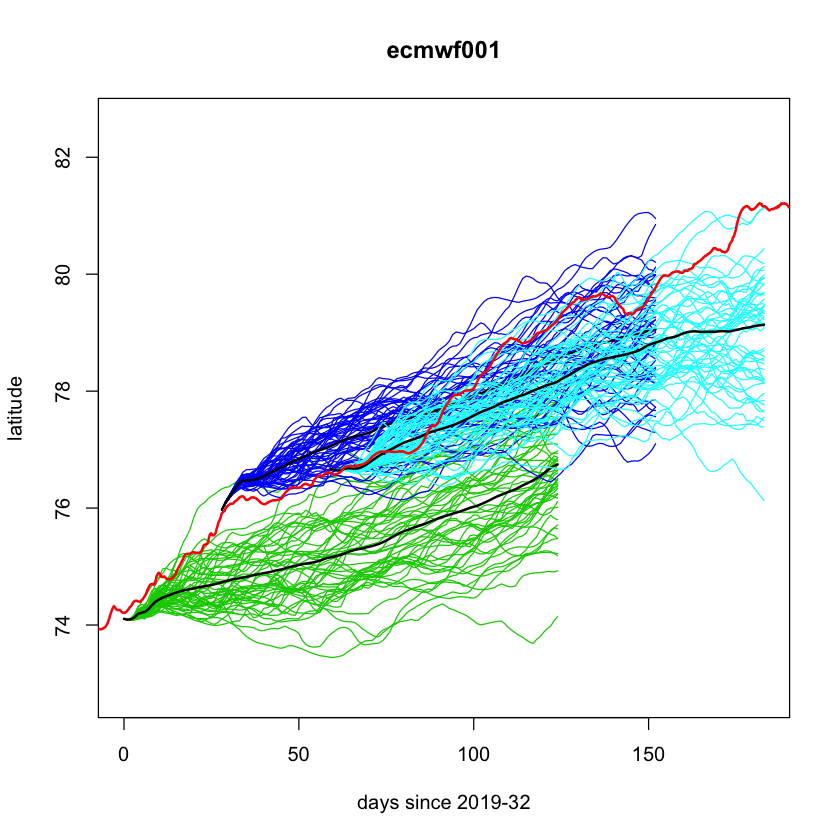

In [15]:
# Plot ECMWF forecast ####
## Start the plot
xlim = c(0,last.time) # set limit for x axis
ylim = extendrange(obs$data$Lat[obs.time >= 0 & obs.time <= last.time], f = 0.2) # set limit for y axis, expanding the range of the data by 20% (probably for plotting)
plot(NA, xlim = xlim, ylim = ylim, xlab = paste0("days since ", RefYear, "-", RefDayOfYear), ylab = "latitude", main = "ecmwf001") # designs the plot
for (i in 1:nFcst) { # loop over forecast ensemble members
    fcst.time = sidfex.ydoy2reltime(Year = fcst$res.list[[i]]$data$Year, DayOfYear = fcst$res.list[[i]]$data$DayOfYear, RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get relative time
    LatColumns = which(substr(names(fcst$res.list[[i]]$data), start = 1, stop = 3) == "Lat") # get columns with latitude. "which" finds those columns whose first 3 letters are eqiuvalent to "Lat"
    if (length(LatColumns) > 1) { # if there is more than one latitude column (multiple members), do the following
        for (latcol in LatColumns[2:length(LatColumns)]) { # loop over latitude columns
            lines(fcst.time,fcst$res.list[[i]]$data[,latcol],col = i+2) # plot latitude vs time. col keyword specifies the color
            }
        }
        lines(fcst.time,fcst$res.list[[i]]$data$Lat, col = "black", lwd = 2) # plot ensemble mean
    }
lines(obs.time, obs$data$Lat, col = "red", lwd = 2) # plot observations

In the next step, we will plot the ESRL forecast in comparison. The code is pretty much the same, only that it uses the ESRL forecast as inoput, which differs both in frequency of initialisation and in lead time. Again, we first define a subindex and get the forecast based on this subindex.

In [16]:
#### Plot ESRL forecast ####
## Get time axis between first and last day of forecast/observation

subindex4 = sidfex.fcst.search.extractFromTable(gid = "esrl001", tid = "300234063991680", iy = c(2019), idoy = c(32,91)) # get info from table (see doc of function for details)

fcst = sidfex.read.fcst(files = subindex4, checkfileformat = FALSE) # get all ESRL forecasts for target 300234063991680 between day 32 and day 91 of 2019. 

nFcst = length(fcst$res.list) # number of forecasts

last.time = sidfex.ydoy2reltime(Year = fcst$res.list[[nFcst]]$LastYear, DayOfYear = fcst$res.list[[nFcst]]$LastDayOfYear,RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get time of last data point (only one time)
## 

Now, as above, we plot the ESRL forecast latitude versus time, as well as the observed latitude.

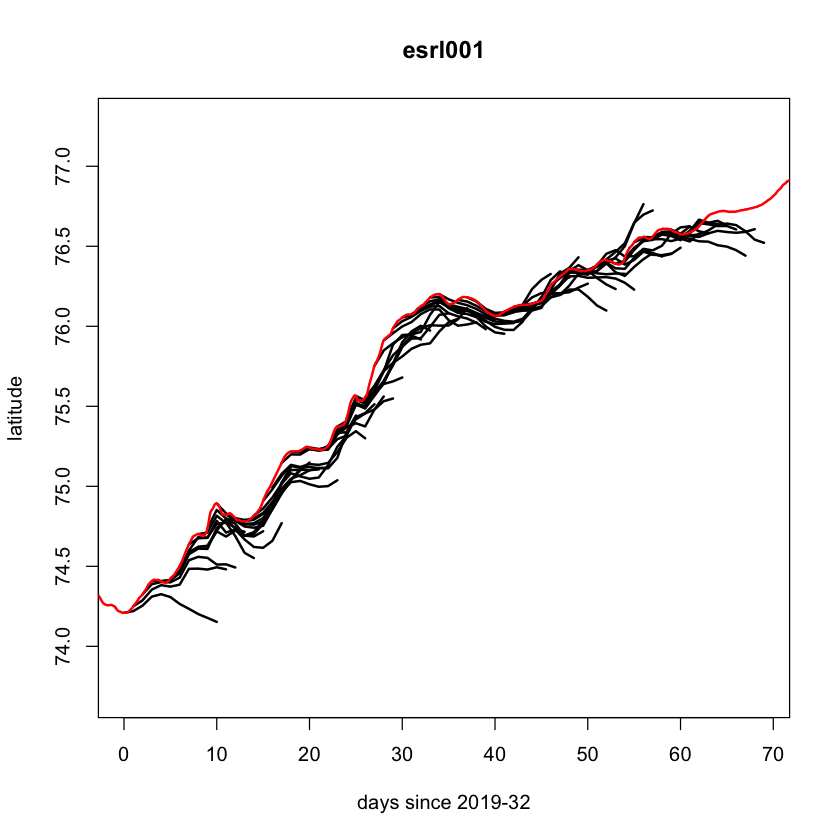

In [17]:
## Start the plot
xlim = c(0,last.time) # set limit for x axis
ylim = extendrange(obs$data$Lat[obs.time >= 0 & obs.time <= last.time], f = 0.2) # set limit for y axis, expanding the range of the data by 20% 
plot(NA, xlim = xlim, ylim = ylim, xlab = paste0("days since ", RefYear, "-", RefDayOfYear), ylab = "latitude", main = "esrl001") # designs the plot
for (i in 1:nFcst) { # loop over forecast ensemble members
    fcst.time = sidfex.ydoy2reltime(Year = fcst$res.list[[i]]$data$Year, DayOfYear = fcst$res.list[[i]]$data$DayOfYear, RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get relative time
    LatColumns = which(substr(names(fcst$res.list[[i]]$data), start = 1, stop = 3) == "Lat") # get columns with latitude. "which" finds those columns whose first 3 letters are eqiuvalent to "Lat"
    if (length(LatColumns) > 1) { # if there is more than one latitude column (multiple members), do the following
        for (latcol in LatColumns[2:length(LatColumns)]) { # loop over latitude columns
        lines(fcst.time,fcst$res.list[[i]]$data[,latcol],col = i+2) # plot latitude vs time. col keyword specifies the color
        }
    }
    lines(fcst.time,fcst$res.list[[i]]$data$Lat, col = "black", lwd = 2) # plot ensemble mean
    }
lines(obs.time, obs$data$Lat, col = "red", lwd = 2) # plot observations
## 

We notice that the lead time is shorter (shorter lines), but the forecasts are initialised more frequently. In the next step, we will use spheRlab for plotting trajectories of the ESRL forecast and of the observed data. Note that, when running this for the very first time, the line ```sl.plot.naturalearth...``` is needed for downloading the natural earth geoinformation (coastlines etc) if you have not yet downloaded it in previous work. It should be stored in ```~/naturalearthdata/```, which should comprise the files:
- ne_10m_coastline.README.html
- ne_10m_coastline.VERSION.txt
- ne_10m_coastline.cpg
- ne_10m_coastline.dbf
- ne_10m_coastline.prj
- ne_10m_coastline.rds
- ne_10m_coastline.shp
- ne_10m_coastline.shx
- ne_50m_coastline.README.html
- ne_50m_coastline.VERSION.txt
- ne_50m_coastline.cpg
- ne_50m_coastline.dbf
- ne_50m_coastline.prj
- ne_50m_coastline.shp
- ne_50m_coastline.shx

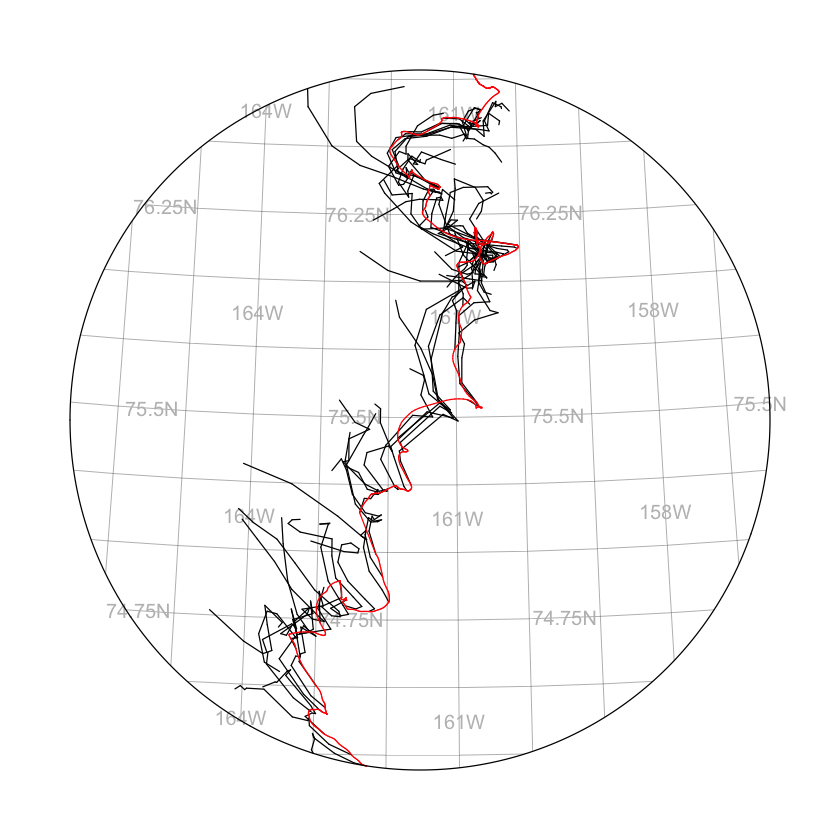

In [21]:
## Now, plot the entire thing as trajectory
which.obs = which(obs.time >= 0 & obs.time <= last.time) # take observations during forecast time
plot.domain = sl.boundingcircle(lon = obs$data$Lon[which.obs], lat = obs$data$Lat[which.obs], verbose = FALSE) # define domain for plot
pir = sl.plot.init(projection = "polar", polar.lonlatrot = c(plot.domain$center_lon,plot.domain$center_lat,0), polar.latbound = 90-plot.domain$radius, do.init.device = FALSE) # start plot
## sl.plot.naturalearth(pir,what = "coastline", resolution = "medium") # This line downloads the coastline file when run for the first time. Unfortunately, the neweset version is not available at this time (see issue on GitHub here: https://github.com/nvkelso/natural-earth-vector/issues/581, but an older version (2.0.0) can be downloaded here: https://www.naturalearthdata.com/downloads/50m-physical-vectors/50m-coastline/ under "Version history". Temporary solution according to comments on above-mentioned issue: Download it from https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip, this should be the newest version
sl.plot.lonlatgrid(pir,labels=TRUE) # add grid lines
for (i in 1:nFcst) { # start loop over forecasts
LatColumns = which(substr(names(fcst$res.list[[i]]$data), start = 1, stop = 3) == "Lat") # extract latitude columns
if (length(LatColumns) > 1) { # loop over all ensemble members if there is more than one
for (latcol in LatColumns[2:length(LatColumns)]){ # loop over members
sl.plot.lines(pir,lon = fcst$res.list[[i]]$data[,latcol + 1], lat = fcst$res.list[[i]]$data[,latcol], col = i+2) # plot line (trajectory) for each member, longitude column selected by latcol + 1 as it is the one after the latitude column
}
}
sl.plot.lines(pir,lon = fcst$res.list[[i]]$data$Lon, lat = fcst$res.list[[i]]$data$Lat, col = "black") # plot line if there was only one member
}
sl.plot.lines(pir, lon = obs$data$Lon[which.obs], lat = obs$data$Lat[which.obs], col = "red") # plot observed trajectory
sl.plot.end(pir, do.close.device = FALSE) # end plotting. If do.close.device == FALSE, device will not be closed, i.e. borders of plot will be removed also for future plots

### Remapping and adjusting data in time and space

Since the starting point and time of the trajectories may differ between systems, it may be necessary to remap and adjust the data for a consistent comparison. This is described in this section. First, a subindex is created as above.

In [22]:
## First off, again, we create an index describing the subdataset which we want to use
subindex3.1 = sidfex.fcst.search.extractFromTable(gid = "ecmwf001", tid = "300234063991680", iy = 2019, idoy = c(32)) # take target as above
fcst = sidfex.read.fcst(files = subindex3.1, checkfileformat = FALSE) # read forecast
obs.time = sidfex.ydoy2reltime(Year = obs$data$Year, DayOfYear = obs$data$POS_DOY, RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get observation time
xlim = c(0, 10) # set xlim of plot
ylim = extendrange(obs$data$Lat[obs.time >= 0& obs.time <= 10], f = 0.2) # set ylim of plot

Now, we plot the latitude of the different ensemble members versus the starting day of year.

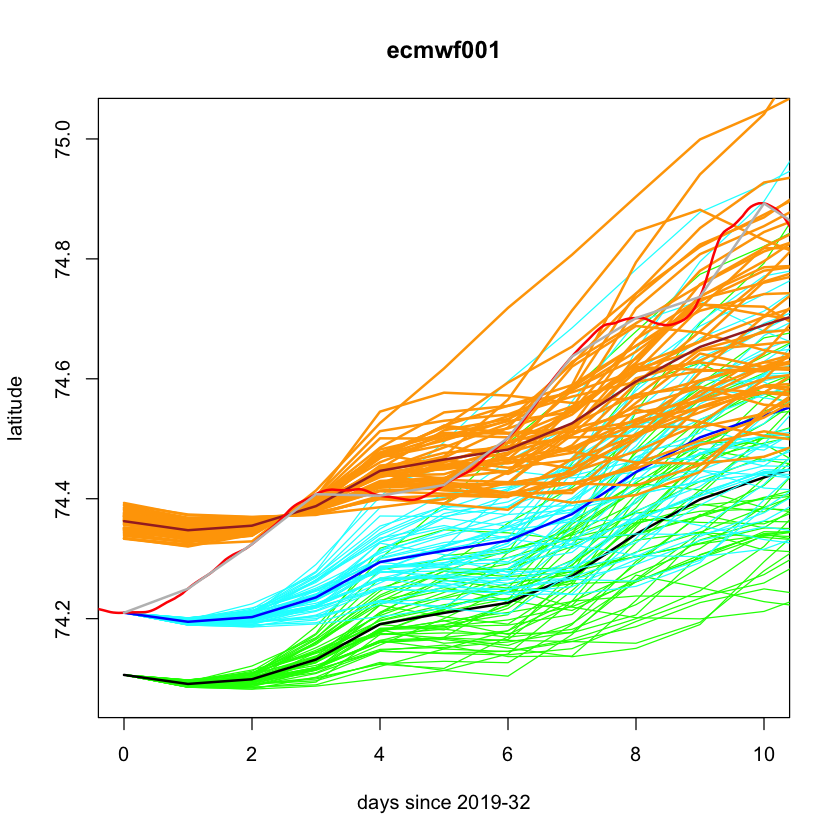

In [36]:
plot(NA, xlim = xlim, ylim = ylim, xlab = paste0("days since ", RefYear, "-", RefDayOfYear), ylab = "latitude", main = "ecmwf001")
## #plot(NA, xlim = xlim, ylim = ylim, xlab = paste0("days since ", RefYear, "-", RefDayOfYear), ylab = "latitude", main = "ecmwf001") # start plot
fcst.time = sidfex.ydoy2reltime(Year = fcst$res.list[[1]]$data$Year, DayOfYear = fcst$res.list[[1]]$data$DayOfYear, RefYear = RefYear, RefDayOfYear = RefDayOfYear) # get forecast time
LatColumns = which(substr(names(fcst$res.list[[1]]$data), start = 1, stop = 3) == "Lat") # get latitude columns
for (latcol in LatColumns[2:length(LatColumns)]) { # loop over ensemble members
    lines(fcst.time, fcst$res.list[[1]]$data[, latcol], col = "green") # plot a line for each ensemble member
    }
lines(fcst.time, fcst$res.list[[1]]$data$Lat, col = "black", lwd = 2) # plot mean line
## 
## ## Adjust initial location
fcst.adj.init = sidfex.rot.fcst(obs = obs, fcst = fcst) # adjust initial location
for (latcol in LatColumns[2:length(LatColumns)]) { # loop over columns (=ensemble members)
    lines (fcst.time,fcst.adj.init$res.list[[1]]$data[, latcol], col = "cyan") # plot a line for each adjusted trajectory
    }
lines(fcst.time, fcst.adj.init$res.list[[1]]$data$Lat, col = "blue", lwd = 2) # plot line for adjusted mean trajectory
## 
## ## Adjust initial location at DOY 34.5
fcst.adj.34.5 = sidfex.rot.fcst(obs = obs, fcst = fcst, obsref.Year = 2019, obsref.DayOfYear = 34.5) # adjust at DOY 34.5
for (latcol in LatColumns[2:length(LatColumns)]){ # loop over columns/ensmble members
    lines(fcst.time, fcst.adj.34.5$res.list[[1]]$data[, latcol], col = "orange", lwd = 2) # plot a line for each newly adjusted trajectory
    }
lines(fcst.time, fcst.adj.34.5$res.list[[1]]$data$Lat, col = "brown", lwd = 2) # plot line for adjusted mean trajectory
## 
## ## Plot observations
lines(obs.time, obs$data$Lat, col = "red", lwd = 2) # plot line for observation
## 
## ## Remap observations to forecast time axis and plot again
obs.remap = sidfex.remaptime.obs2fcst(obs = obs, fcst = fcst) # remap observations
obs.remap.time = sidfex.ydoy2reltime(Year = obs.remap$res.list[[1]]$data$Year, DayOfYear = obs.remap$res.list[[1]]$data$DayOfYear, RefYear = RefYear, RefDayOfYear = RefDayOfYear) # convert time of remapped observation to relative time
lines(obs.remap.time, obs.remap$res.list[[1]]$data$Lat, col = "grey", lwd = 2) # plot this remapped observation
## ###############

### Quantitative evaluation

Having collected first steps with displaying the data, we will now take a step forward and do some more quantitative evaluation. First, we produce a so-called speed angle plot, which shows us how far the system was from the observation in terms of drift speed and drift angle

Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”

[1] "values for 'DaysLeadTime' to determine the colourbar are in the following range:"
  0%  25%  50%  75% 100% 
   0   31   62   93  124 


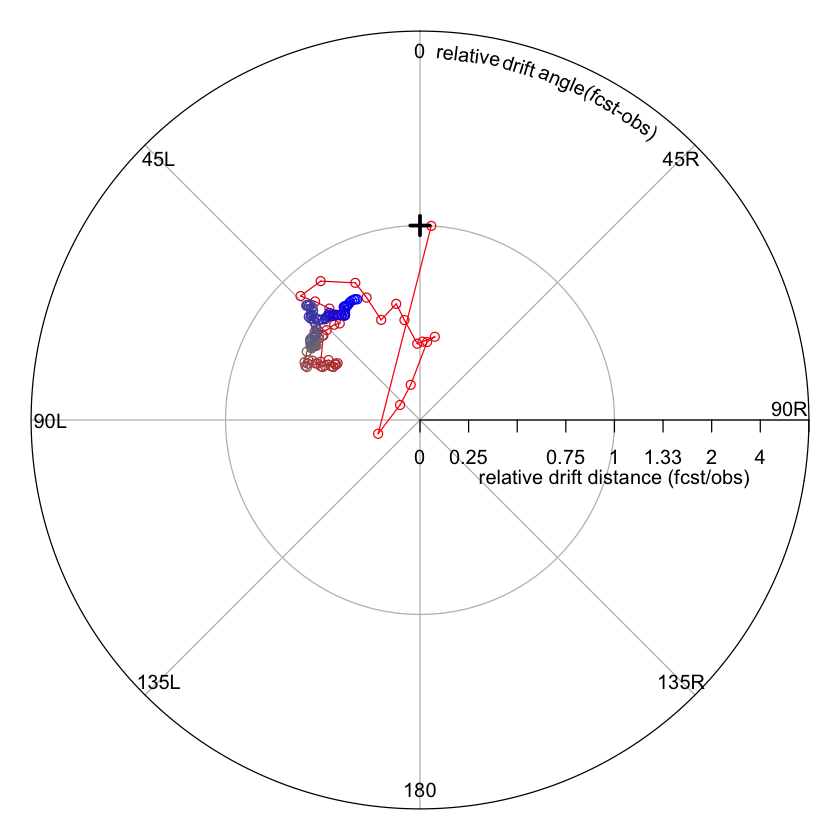

In [20]:
## Speedangle plot
errs = sidfex.evaluate(fcst = fcst.adj.init) # evaluate forecast which was adjusted to initial date
colbar = sidfex.plot.speedangle(read.fcst.res = fcst.adj.init, points.type = "b", col.by = "DaysLeadTime", device = NULL) # make speedangle plot

The distance of the forecast trajectory from the center of the circle tells us the relative drift speed (forecast speed divided by observed speed), so in this case the forecast was slower than the observation. Also, the angle of the drift was off: The forecast was about 45° to the left of the observation.

For our analysis, we will have a closer look at the relative performance of some systems. We again select them by defining a subindex and then constructing a data frame.

In [47]:
tb1

,nFcst,leadtimerange,enssize,nTimeSteps
awi001_ClimRunVers2019May,94,39.94681,8.893617,85.76596
eccc001_giops,94,39.94681,8.893617,85.76596
ecmwf001_SEAS5,94,39.94681,8.893617,85.76596
esrl001_SeaIceVelocity,94,39.94681,8.893617,85.76596
metno001_RK2,94,39.94681,8.893617,85.76596
ncep001_freedrift-ensmean,94,39.94681,8.893617,85.76596
nrl001_gofs3.1-shortrange,94,39.94681,8.893617,85.76596
nrl001_navyespc-subseasonal,94,39.94681,8.893617,85.76596
ukmo001_cplNWP,94,39.94681,8.893617,85.76596
ukmo001_cplNWP-HR,94,39.94681,8.893617,85.76596


In [48]:
### Warning: Selecting ther subindex subind.allmethods takes quite long to run. Only run if really needed ###
## More quantitative evaluation
subind.allmethods = sidfex.fcst.search.extractFromTable(tid = "300234061872720", iy = c(2018,2019), idoy = c(335,74), InheritFromParent = TRUE) # get all forecasts for all systems for target tid between 2018, day 335 and 2019, day 74

In [62]:
systms = paste(subind.allmethods$GroupID,subind.allmethods$MethodID, sep = "_") # get list with strings describing the systems
systms_unique = unique(systms) # get list with duplicates removed from systms
tb1 = as.data.frame(matrix(nrow = length(systms_unique), ncol = 4)) # intialise data frame
rownames(tb1) = systms_unique # use system names as row names
colnames(tb1) = c("nFcst", "leadtimerange", "enssize", "nTimeSteps") # use string for variable as column names
for (i in 1:length(systms_unique)) { # loop over system names
    print(paste0("Handling system ", systms_unique[i], " (",i,"/",length(systms_unique),")"))
    indices = (systms == systms_unique[i]) # get boolean vector of system
    tb1[i,1] = sum(indices) # get number of forecasts (sum of boolean values)
    tb1[i,2] = mean(subind.allmethods$FcstTime[indices]) # get mean forecast time
    tb1[i,3] = mean(subind.allmethods$EnsSize[indices]) # get mean ensemble size
    tb1[i,4] = mean(subind.allmethods$nTimeSteps[indices]) # get mean number of time steps
    }

[1] "Handling system awi001_ClimRunVers2019May (1/11)"
[1] "Handling system eccc001_giops (2/11)"
[1] "Handling system ecmwf001_SEAS5 (3/11)"
[1] "Handling system esrl001_SeaIceVelocity (4/11)"
[1] "Handling system metno001_RK2 (5/11)"
[1] "Handling system ncep001_freedrift-ensmean (6/11)"
[1] "Handling system nrl001_gofs3.1-shortrange (7/11)"
[1] "Handling system nrl001_navyespc-subseasonal (8/11)"
[1] "Handling system ukmo001_cplNWP (9/11)"
[1] "Handling system ukmo001_cplNWP-HR (10/11)"
[1] "Handling system ukmo001_FOAM (11/11)"


In [65]:
tb1 # show us what tb1 looks like

,nFcst,leadtimerange,enssize,nTimeSteps
awi001_ClimRunVers2019May,30,364,10,365
eccc001_giops,100,10,1,481
ecmwf001_SEAS5,153,124,51,125
esrl001_SeaIceVelocity,101,10,1,11
metno001_RK2,105,9,1,9
ncep001_freedrift-ensmean,74,16,1,16
nrl001_gofs3.1-shortrange,105,6,1,7
nrl001_navyespc-subseasonal,60,43,4,44
ukmo001_cplNWP,101,11,1,12
ukmo001_cplNWP-HR,101,11,1,12


For the analysis, we now read the actual forecasts.

In [66]:
## ##
systms_selected = systms_unique[(tb1$nFcst/tb1$enssize > 10)] # select those systems which have more than 10 forecasts in the considered period (different members of one ensemble count as one forecast, therefore the division by tb1$enssize)
## Remove two systems which are not in the user guide example
#systms_selected = systms_selected[which(systms_selected != "awi001_ClimRunVers2019May")] # remove awi001_ClimRunVers2019May from list of selected systems
#systms_selected = systms_selected[which(systms_selected != "ecmwf001_SEAS5")]# remove ecmwf001_SEAS5 from list of selected systems
Nmethods = length(systms_selected) # number of so-selected systems
remap.time = seq(0, 10) # sequence of numbers from 0 to 10, including the end
eval.results = list() # preallocate list with results 
for (i in 1:Nmethods) { # loop over systems
    subind = subind.allmethods[systms %in% systms_selected[i], ] # get all forecasts for system currently looped over
    fcst.orig = sidfex.read.fcst(files = subind, checkfileformat = FALSE, verbose = FALSE) # read original forecasts
    fcst.remap = sidfex.remaptime.fcst(fcst = fcst.orig, newtime.DaysLeadTime = remap.time, verbose = FALSE) # remap to new time axis
    fcst.adjust = sidfex.rot.fcst(fcst = fcst.remap) # rotate forecast
    eval.results[[i]] = sidfex.evaluate(fcst = fcst.adjust, verbose = FALSE)$multifcst.stats # evaluate forecast
    }


Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“data time stamps not always ascending; reordered”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“data time stamps not always ascending; reordered”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“data time stamps not always ascending; reordered”Warning message in sidfex.read.obs(TargetID = unique(sapply(fcst$res.list, "[[", :
“duplicates removed; using only respective last values”Warning message in sidfex.read.obs(TargetID = uni

In the next cell, we will plot the great-circle distance vs. the lead time for each system (solid lines), including a 2$\sigma$ error margin (dashed lines).

In [67]:
## 
plotdir = "./plots/" # define filepath where plot shall be saved

[1] "eccc001_giops"
[1] "esrl001_SeaIceVelocity"
[1] "metno001_RK2"
[1] "ncep001_freedrift-ensmean"
[1] "nrl001_gofs3.1-shortrange"
[1] "nrl001_navyespc-subseasonal"
[1] "ukmo001_cplNWP"
[1] "ukmo001_cplNWP-HR"
[1] "ukmo001_FOAM"


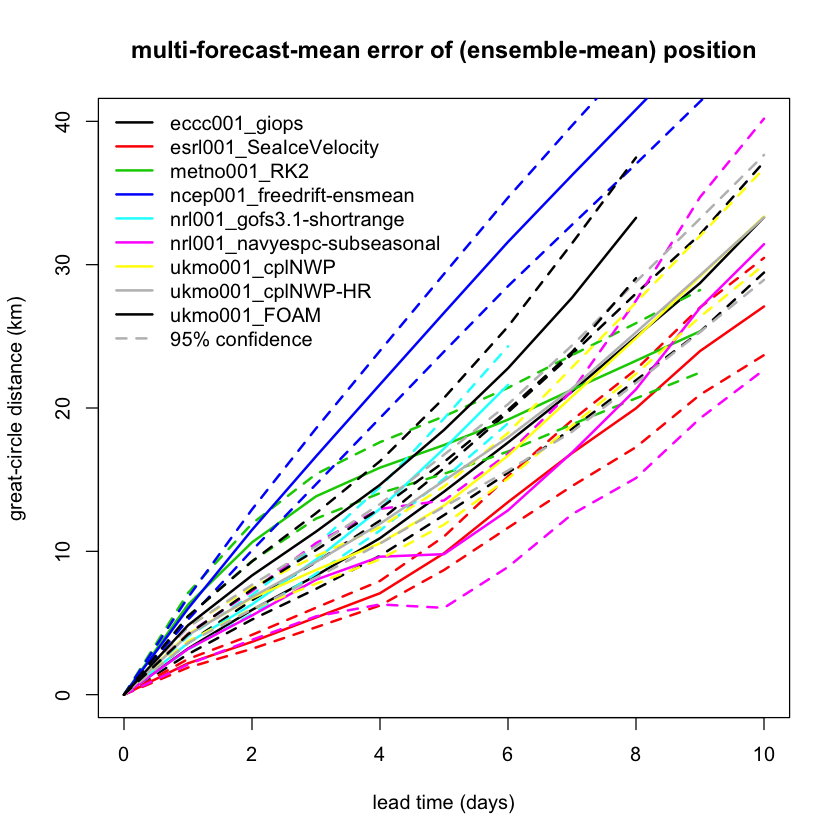

In [68]:

#pdf(paste0(plotdir,"multi_fcst_mean_error.pdf") ) # open file where plot shall be saved. In this case, plot will not be showed here!
plot(NA, xlim = range(remap.time), ylim = c(0,40), main = "multi-forecast-mean error of (ensemble-mean) position", xlab = "lead time (days)", ylab = "great-circle distance (km)") # design plot
for (i in 1:Nmethods) { # start to loop over systems
    print(systms_selected[[i]]) # print currently used system
    dat = eval.results[[i]]$ens.mean.gc.dist/1000 # get ensemble mean distance
    lines(remap.time, dat$mean + 2*dat$st.err, col = i, lty = 2, lwd = 2) # plot upper bound (mean + 2sigma)
    lines(remap.time, pmin(dat$mean - 2*dat$st.err), col = i, lty = 2, lwd = 2) # plot lower bound (mean - 2 sigma)
    lines(remap.time, dat$mean, col = i, lwd = 2) # plot mean
    }
legend("topleft", legend = c(systms_selected, "95% confidence"), lty = c(rep(1,Nmethods), 2), bty = "n", col = c(1:Nmethods, 8), lwd = 2) # add legend
#dev.off() # turn off device

In our last example, we choose one system and compare the error of the ensemble mean to the ensemble spread.

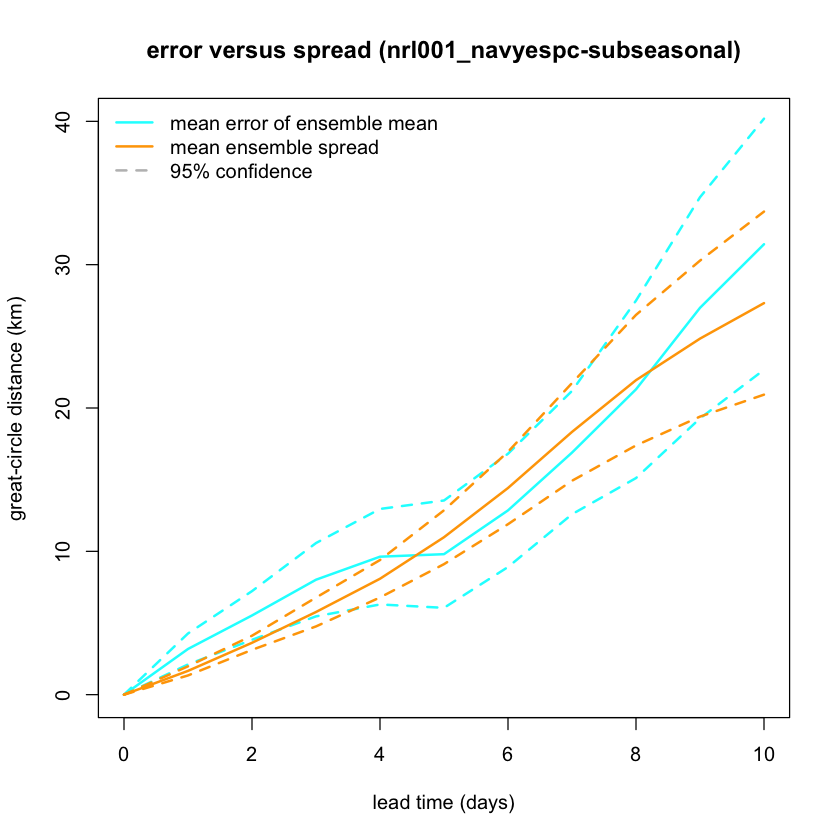

In [69]:
#pdf(paste0(plotdir,"error_vs_spread.pdf") ) # open file for saving next plot. In this case, plot will not be showed here!
plot(NA, xlim  = range(remap.time), ylim = c(0,40), main = "error versus spread (nrl001_navyespc-subseasonal)", xlab = "lead time (days)", ylab = "great-circle distance (km)") # design plot
i = which(systms_selected == "nrl001_navyespc-subseasonal") # use only nrl001_navyespc-subseasonal 
dat = eval.results[[i]]$ens.mean.gc.dist/1000 # get mean distance 
lines(remap.time, dat$mean + 2*dat$st.err, col = "cyan", lty = 2, lwd = 2) # plot plus 2 sigma line
lines(remap.time, dat$mean - 2*dat$st.err, col = "cyan", lty = 2, lwd = 2) # plot minus 2 sigma line
lines(remap.time, dat$mean, col = "cyan", lwd = 2) # plot mean

dat = eval.results[[i]]$ens.spread.gc.dist/1000 # get spread
lines(remap.time, dat$mean + 2*dat$st.err, col = "orange", lty = 2, lwd = 2) # plot plus 2 sigma line
lines(remap.time, dat$mean - 2*dat$st.err, col = "orange", lty = 2, lwd = 2) # plot minus 2 sigma line
lines(remap.time, dat$mean, col = "orange", lwd = 2) # plot mean
legend("topleft", legend = c("mean error of ensemble mean", "mean ensemble spread", "95% confidence"), col = c("cyan", "orange", "grey"), bty = "n", lty = c(1,1,2), lwd = 2) # add legend
#dev.off() # turn off device (finish saving the plot)

## Closing remarks

- This user guide gave you a first glimpse on what the SIDFEx database comprises and how the SIDFEx R package can be used. Now, you are ready to explore the dataset on your own. Do not hesitate to contact us at ```valentin.ludwig@awi.de```or ```helge.goessling@awi.de```if you have more questions or run into problems, we are happy to help.
- Did something disturb you when working with the user guide? Let us know! We will be happy to address your concerns and to continuously improve the user guide.